# Analyse spatiale des prix immobiliers à Paris

De nouvelles bases publiques permettent d'accéder à l'univers des transactions immobilières françaises (base des notaires, DV3F) avec informations de prix, surface et localisation. L'objectif de ce projet est d'offrir une analyse très locale de la variabilité des prix du logement à Paris et de comprendre le fort degré d'hétérogénéité intra-arrondissement.

Sources de données :
- **DVF+ Open Data (Cerema)** : transactions immobilières sur Paris, département 75.
- **Etalab / data.gouv.fr** : référentiel DVF géocodé (coordonnées des parcelles cadastrales).
- **Open Data Paris** : frontières administratives des arrondissements (format GeoJSON).

Plan :
1. **Phase 1** : Nettoyage DVF (agrégation par `idmutation`, filtres sur VEFA, typologie, bornes de prix), statistiques descriptives par arrondissement, et visualisation de la dispersion intra-arrondissement.
2. **Phase 2** : Descente d'échelle géographique (section cadastrale) et décomposition de la variance (R² ajusté) par régression OLS avec dummies géographiques.
3. **Phase 3** : Géocodage via Etalab, régionalisation spatiale contrainte (méthode de Ward et graphe de voisinage k-NN), et comparaison cartographique avec les frontières administratives actuelles de l'INSEE.
4. **Phase 4** : Massification temporelle des données (2021-2024) et justification du nombre de clusters optimal via la méthode du coude économique et les métriques de séparation spatiale.

---
Stack technique : pandas, numpy, scipy, matplotlib, seaborn, scikit-learn, statsmodels, folium.


# Phase 1 : Variabilité par arrondissement des prix immobiliers à Paris

**Objectif :** Analyser l'hétérogénéité des prix de l'immobilier à Paris à partir des données DVF (Demandes de Valeurs Foncières).
On se concentre sur l'importation, le nettoyage de l'échantillon brut, et les premières statistiques descriptives par arrondissement.

## 1. Préparation de l'environnement et chargement des données

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

pd.set_option('display.max_columns', 50)

df = pd.read_csv("mutations_d75.csv", sep=";")

df.head(3)

,idmutation,idmutinvar,idopendata,idnatmut,codservch,refdoc,datemut,anneemut,moismut,coddep,libnatmut,vefa,valeurfonc,nbdispo,nblot,nbcomm,l_codinsee,nbsection,l_section,nbpar,l_idpar,nbparmut,l_idparmut,nbsuf,sterr,...,nbapt2pp,nbapt3pp,nbapt4pp,nbapt5pp,nbmai1pp,nbmai2pp,nbmai3pp,nbmai4pp,nbmai5pp,sbati,sbatmai,sbatapt,sbatact,sapt1pp,sapt2pp,sapt3pp,sapt4pp,sapt5pp,smai1pp,smai2pp,smai3pp,smai4pp,smai5pp,codtypbien,libtypbien
0,12720526,b5b875cc3e82afbe1559b1bbeab6157f,b5b875cc3e82afbe1559b1bbeab6157f,2,NaN,NaN,2014-10-30,2014,10,75,Vente en l'état futur d'achèvement,True,360000.0,1,1,1,['75119'],1,['AO'],1,['75119000AO0086'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif
1,12738160,120ee7765ec5c132c3ad1394fb4eb803,120ee7765ec5c132c3ad1394fb4eb803,2,NaN,NaN,2014-04-24,2014,4,75,Vente en l'état futur d'achèvement,True,334000.0,1,1,1,['75114'],1,['CY'],1,['75114000CY0059'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif
2,12739989,58195de5cc7c8af9065123a10921548e,58195de5cc7c8af9065123a10921548e,2,NaN,NaN,2014-06-06,2014,6,75,Vente en l'état futur d'achèvement,True,369420.0,1,1,1,['75114'],1,['CY'],1,['75114000CY0059'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif


## 2. Nécessité de nettoyer et restreindre l'échantillon

L'échantillon brut contient l'univers complet des transactions. Pour obtenir un prix au $m^2$ pertinent, plusieurs traitements sont indispensables :
1. **Filtres de base :** Il faut ne conserver que les "ventes" classiques d'appartements (exclusion des ventes sur plan/VEFA, terrains, locaux commerciaux).
2. **Agrégation des transactions :** Dans la base DVF, une transaction comprenant plusieurs lots génère plusieurs lignes, mais la valeur foncière globale est répétée sur chaque ligne. On doit alors regrouper les données par `idmutation` (la transaction) pour sommer les surfaces avant de calculer le prix, sous peine de biaiser les résultats.

In [20]:
# Filtres de base
df_clean = df[
    (df['libnatmut'] == 'Vente') & 
    (df['vefa'] == False) &
    (df['libtypbien'].str.contains('APPARTEMENT', na=False)) &
    (df['valeurfonc'] > 0) & 
    (df['sbati'] >= 9)
].copy()

# Agrégation par transaction (idmutation)
df_clean = df_clean.groupby('idmutation').agg({
    'valeurfonc': 'first',
    'sbati': 'sum',
    'l_codinsee': 'first',
    'anneemut': 'first',
    'l_section': 'first',
    'l_idpar' : 'first'
}).reset_index()

# Calcul du prix au m2
df_clean['prix_m2'] = df_clean['valeurfonc'] / df_clean['sbati']

# Suppression des valeurs statistiques aberrantes (erreurs de saisie)
df_clean = df_clean[
    (df_clean['prix_m2'] > 1000) & 
    (df_clean['prix_m2'] < 30000)
]

print(f"Nombre de transactions avant nettoyage : {len(df)}")
print(f"Nombre de transactions viables après nettoyage : {len(df_clean)}")

Nombre de transactions avant nettoyage : 457097
Nombre de transactions viables après nettoyage : 337417


## 3. Statistiques Descriptives Globales

Maintenant que le biais des surfaces partielles et des erreurs de saisie est écarté, nous pouvons calculer des statistiques descriptives sur l'ensemble de la ville.

In [21]:
print("--- Statistiques Globales (Paris) ---")
print("Prix moyen au m2 :", round(df_clean['prix_m2'].mean(), 2), "€")
print("Prix médian au m2 :", round(df_clean['prix_m2'].median(), 2), "€")
print("Prix minimum au m2 :", round(df_clean['prix_m2'].min(), 2), "€")
print("Prix maximum au m2 :", round(df_clean['prix_m2'].max(), 2), "€")

--- Statistiques Globales (Paris) ---
Prix moyen au m2 : 9730.55 €
Prix médian au m2 : 9500.0 €
Prix minimum au m2 : 1000.71 €
Prix maximum au m2 : 29975.0 €


## 4. Hétérogénéité spatiale : Analyse inter-arrondissements

En préparation de l'analyse spatiale demandée par le projet, nous formatons les codes géographiques (INSEE) pour extraire le numéro de l'arrondissement. Nous calculons ensuite le prix moyen par secteur géographique pour observer les premières disparités.

--- Tableau récapitulatif par Arrondissement ---


,Nb_Ventes,Surface_Moyenne_m2,Prix_moyen_m2,Prix_median_m2
arrondissement,,,,
1,3412,58.0,11943.0,11587.0
2,5130,48.0,10698.0,10725.0
3,7296,53.0,11330.0,11251.0
4,5442,57.0,12278.0,12092.0
5,8945,53.0,11553.0,11522.0
6,8430,69.0,13722.0,13422.0
7,9815,84.0,13551.0,13056.0
8,7526,94.0,11598.0,11227.0
9,12420,59.0,10256.0,10259.0


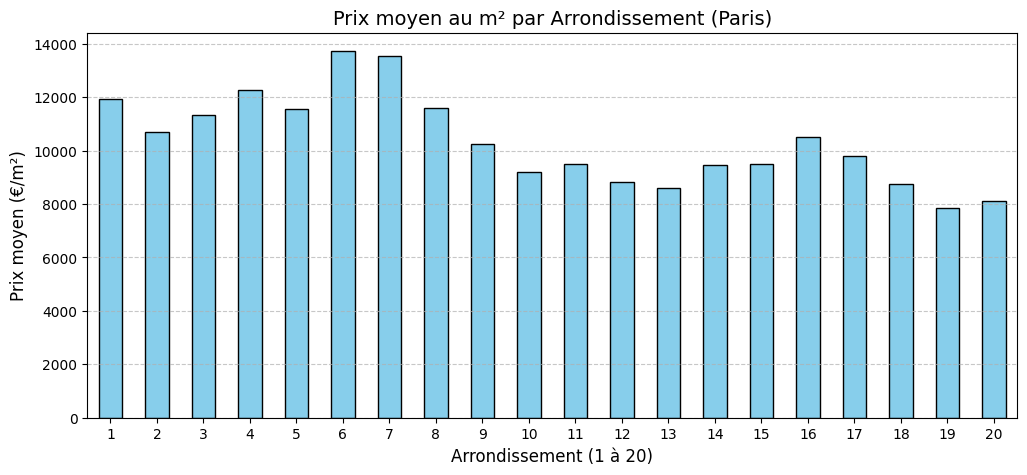

In [22]:
# Nettoyage de l'arrondissement
def extraire_numero_arrondissement(valeur):
    try:
        code = ast.literal_eval(valeur)[0]
        return int(code[-2:])
    except:
        return None

df_clean['arrondissement'] = df_clean['l_codinsee'].apply(extraire_numero_arrondissement)
df_clean = df_clean.dropna(subset=['arrondissement']) 

# Tableau descriptif par arrondissement
resume_arrondissement = df_clean.groupby('arrondissement').agg(
    Nb_Ventes=('idmutation', 'count'),          # Volume
    Surface_Moyenne_m2=('sbati', 'mean'),       # Typologie
    Prix_moyen_m2=('prix_m2', 'mean'),          # Prix
    Prix_median_m2=('prix_m2', 'median')        # Prix médian
).round(0)

print("--- Tableau récapitulatif par Arrondissement ---")
display(resume_arrondissement)
print("\n")

# Diagramme en barres des prix moyens
plt.figure(figsize=(12, 5))
resume_arrondissement['Prix_moyen_m2'].plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Prix moyen au m² par Arrondissement (Paris)', fontsize=14)
plt.ylabel('Prix moyen (€/m²)', fontsize=12)
plt.xlabel('Arrondissement (1 à 20)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

plt.show()

## 5. Dispersion intra-arrondissement

La moyenne observée précédemment lisse les variations. Nous pouvons aussi observer la dispersion des prix à l'intérieur de chaque arrondissement sous forme de boxplot pour se rapprocher de ce qui nous intéresse dans la suite du projet.

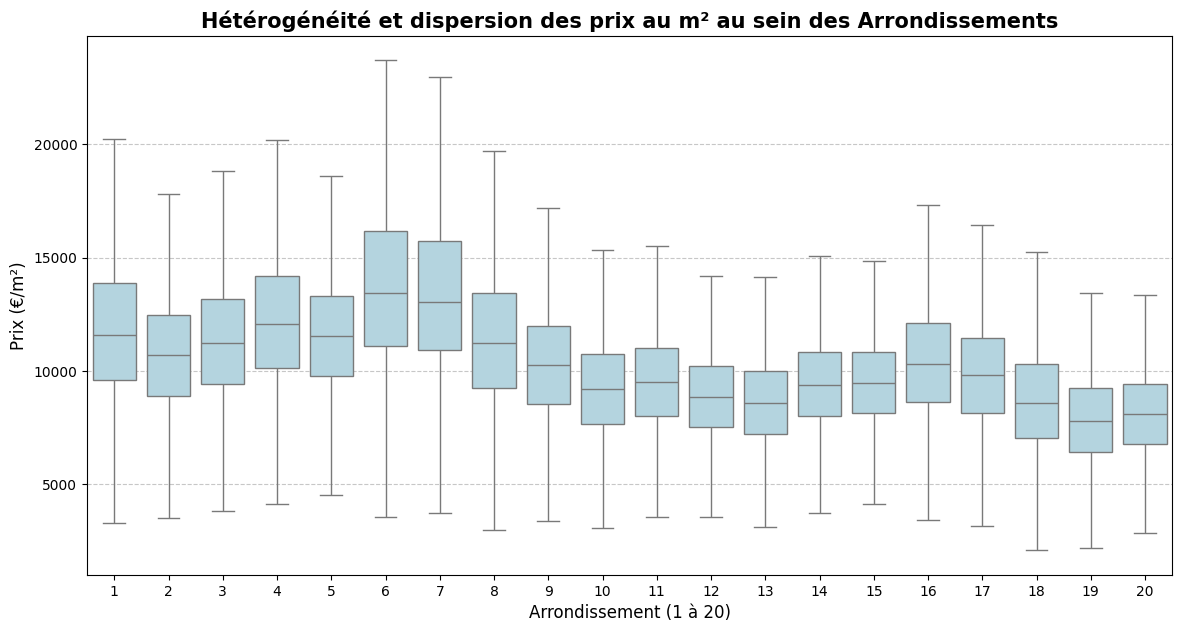

In [23]:
# Boxplot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_clean, 
    x='arrondissement', 
    y='prix_m2', 
    color='lightblue', 
    showfliers=False # On masque les aberrations isolées pour la lisibilité
)

plt.title('Hétérogénéité et dispersion des prix au m² au sein des Arrondissements', fontsize=15, fontweight='bold')
plt.ylabel('Prix (€/m²)', fontsize=12)
plt.xlabel('Arrondissement (1 à 20)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Conclusion de la phase 1

1. **La nécessité méthodologique :** L'exploitation des données DVF brutes requiert un retraitement strict (exclusion des VEFA, agrégation par transaction) pour garantir la fiabilité de la variable "prix au m²". Même les traitements appliqués ne sont pas sûrs : les bornes de prix que l'on utilise pour filtrer sont arbitraires et il se peut que nous en supprimions trop ou pas assez.
2. **Une double hétérogénéité :** Les résultats confirment une forte disparité inter-arrondissements, mais surtout une variance très élevée **au sein même** de certains arrondissements (visibles sur l'étalement des boxplots).
3. **Perspectives :** Pour comprendre l'origine de cette hétérogénéité locale (proximité des transports, espaces verts, bruit...), il sera nécessaire de passer à une approche micro-locale, en utilisant des coordonnées géographiques plus fines (carreaux de 200m, IRIS).

## Remarques méthodologiques et limites de l'exercice

Le nettoyage de la base de données a conduit à écarter environ 26 % des observations initiales (passant de ~457k lignes brutes à ~337k transactions viables). Cette "purge" a permis d'éliminer :
- Les données aberrantes ou incomplètes (ex: ventes en VEFA avec surface bâtie non encore déclarée).
- Les transactions "non-significatives" du marché de l'habitat résidentiel (caves, parkings, locaux commerciaux, terrains).
- Les ventes symboliques, intrafamiliales ou échanges (ex: des transactions affichées à 1€ ou à des prix au m² irréalistes).
- Les micro-surfaces (inférieures à 9 m²), dont la dynamique de prix au m² est spéculative et déconnectée du marché classique du logement.

# Phase 2 : Variance intra-arrondissement et Micro-Entités

**Objectif :** Répondre à la problématique de l'hétérogénéité spatiale en vérifiant si des "sous-entités" géographiques plus petites expliquent mieux la variance des prix que les frontières administratives de l'INSEE. Notre méthodologie est triple :

1. **Contrôle temporel :** L'immobilier étant soumis à l'inflation et aux cycles, nous isolons l'année comptant le plus de transactions. Cela permet de comparer des prix constants et de s'assurer que la variance mesurée est bien géographique, et non temporelle.
2. **Le proxy "Micro-Quartier" :** En l'absence de coordonnées XY exactes dans les données, nous exploitons la **Section Cadastrale** (`l_section`). Le cadastre découpe chaque arrondissement en sections (regroupements convexes de quelques îlots ou rues). C'est l'entité micro-locale naturelle.
3. **Analyse de dispersion :** Nous comparerons l'écart-type (la dispersion) des prix au sein des arrondissements globaux avec celui observé au sein de ces sections cadastrales.

In [24]:
import numpy as np

# 1. Filtre temporel : neutraliser le cycle du marché
annees_disponibles = [2021, 2022, 2023, 2024]
print(f"Années géocodées disponibles en local : {annees_disponibles}")

annee_max = df_clean['anneemut'].value_counts().idxmax()
annee_input = input("Choisissez l'année d'analyse (appuyez sur Entrée pour 2022 par défaut) : ")

# Année la plus liquide par défaut
if annee_input.isdigit() and int(annee_input) in annees_disponibles:
    annee = int(annee_input)
else:
    annee = annee_max

print(f"-> Année retenue pour l'analyse : {annee}")

df_annee = df_clean[df_clean['anneemut'] == annee].copy()

# 2. Extraction propre des données de localisation (Listes sous forme de texte)
def extraire_element(valeur):
    try:
        if pd.isna(valeur): return np.nan
        return ast.literal_eval(valeur)[0]
    except:
        return np.nan

def extraire_numero_arr(valeur):
    try:
        code = ast.literal_eval(valeur)[0]
        return int(code[-2:])
    except:
        return None

df_annee['section'] = df_annee['l_section'].apply(extraire_element)
df_annee['arrondissement'] = df_annee['l_codinsee'].apply(extraire_numero_arr)

# 3. Création de l'entité spatiale "Micro-Quartier"
df_spatial = df_annee.dropna(subset=['arrondissement', 'section']).copy()
df_spatial['micro_quartier'] = df_spatial['arrondissement'].astype(str) + "_" + df_spatial['section']

# Filtre de robustesse : au moins 5 ventes
sections_valides = df_spatial.groupby('micro_quartier').filter(lambda x: len(x) >= 5)

print(f"\n--- Périmètre de l'analyse spatiale ---")
print(f"Nombre de transactions étudiées : {len(sections_valides)}")
print(f"Nombre de micro-quartiers (Sections) étudiés : {sections_valides['micro_quartier'].nunique()}")

Années géocodées disponibles en local : [2021, 2022, 2023, 2024]


-> Année retenue pour l'analyse : 2022

--- Périmètre de l'analyse spatiale ---
Nombre de transactions étudiées : 34710
Nombre de micro-quartiers (Sections) étudiés : 1025


## 1. Preuve statistique : La réduction de la variance

Nous calculons la dispersion moyenne (l'écart-type) subie par un acheteur au sein d'un arrondissement, et nous la comparons à la dispersion au sein d'un micro-quartier. Si la géographie micro-locale joue un rôle, la dispersion doit mathématiquement baisser.

In [25]:
# Écart-type (dispersion) moyen intra-arrondissement vs intra-section
std_arrondissement = sections_valides.groupby('arrondissement')['prix_m2'].std().mean()
std_section = sections_valides.groupby('micro_quartier')['prix_m2'].std().mean()

baisse_variance = ((std_arrondissement - std_section) / std_arrondissement) * 100

print(f"Écart-type moyen au sein d'un Arrondissement : {std_arrondissement:.0f} €/m²")
print(f"Écart-type moyen au sein d'un Micro-Quartier : {std_section:.0f} €/m²")
print(f"-> Gain de précision (Baisse de la dispersion) : -{baisse_variance:.1f} %\n")

Écart-type moyen au sein d'un Arrondissement : 3045 €/m²
Écart-type moyen au sein d'un Micro-Quartier : 2640 €/m²
-> Gain de précision (Baisse de la dispersion) : -13.3 %



## 2. Cartographie de l'hétérogénéité par arrondissement

La moyenne globale de 13,3% cache de fortes disparités. La pertinence d'une frontière administrative n'est pas la même dans le centre historique que dans les arrondissements périphériques. Nous allons donc calculer le gain de précision apporté par la subdivision pour chaque arrondissement individuellement.

In [26]:
# 1. Calcul de la dispersion globale de chaque arrondissement (sans subdivision)
dispersion_arr = sections_valides.groupby('arrondissement')['prix_m2'].std().rename('Std_Arrondissement')

# 2. Calcul de la dispersion moyenne des sections à l'intérieur de chaque arrondissement
dispersion_sect = sections_valides.groupby(['arrondissement', 'micro_quartier'])['prix_m2'].std().groupby('arrondissement').mean().rename('Std_Moyenne_Sections')

# 3. Fusion et calcul du Gain de Précision
analyse_heterogeneite = pd.concat([dispersion_arr, dispersion_sect], axis=1).dropna()
analyse_heterogeneite['Baisse_Variance_%'] = ((analyse_heterogeneite['Std_Arrondissement'] - analyse_heterogeneite['Std_Moyenne_Sections']) / analyse_heterogeneite['Std_Arrondissement']) * 100

# Tri pour voir quels arrondissements bénéficient le plus de la subdivision
analyse_heterogeneite = analyse_heterogeneite.sort_values('Baisse_Variance_%', ascending=False)

print("--- Analyse de l'hétérogénéité intra-arrondissement ---")
display(analyse_heterogeneite.round(1))

--- Analyse de l'hétérogénéité intra-arrondissement ---


,Std_Arrondissement,Std_Moyenne_Sections,Baisse_Variance_%
arrondissement,,,
18,2663.8,2167.0,18.7
19,2208.7,1882.6,14.8
14,2678.0,2299.2,14.1
8,4201.3,3738.2,11.0
13,2303.9,2074.0,10.0
10,2515.8,2269.6,9.8
16,3506.5,3174.1,9.5
15,2483.9,2254.8,9.2
7,4447.0,4079.5,8.3


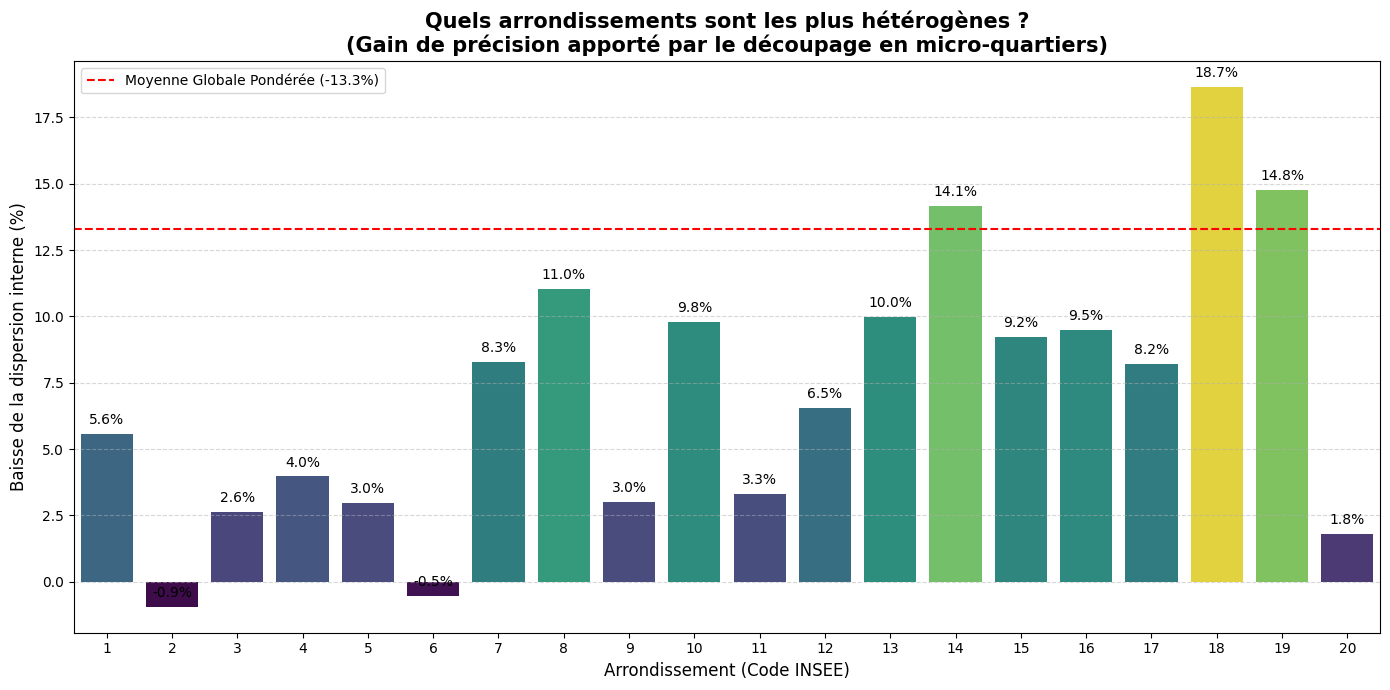

In [27]:
plt.figure(figsize=(14, 7))

# On trace un graphique en barres ordonné
ax = sns.barplot(
    x=analyse_heterogeneite.index, 
    y=analyse_heterogeneite['Baisse_Variance_%'], 
    palette="viridis",
    hue=analyse_heterogeneite['Baisse_Variance_%'],
    legend=False
)

plt.title("Quels arrondissements sont les plus hétérogènes ?\n(Gain de précision apporté par le découpage en micro-quartiers)", fontsize=15, fontweight='bold')
plt.ylabel("Baisse de la dispersion interne (%)", fontsize=12)
plt.xlabel("Arrondissement (Code INSEE)", fontsize=12)
plt.axhline(baisse_variance, color='red', linestyle='--', label=f"Moyenne Globale Pondérée (-{baisse_variance:.1f}%)")

# Ajout des valeurs sur les barres
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Pouvoir explicatif et décomposition de la variance (ANOVA)

Nous avons observé que les micro-quartiers réduisent l'erreur de dispersion. Pour quantifier cela de manière économétrique, nous modélisons le pouvoir explicatif de la géographie sur le prix. 

Nous comparons deux modèles de régression (Moindres Carrés Ordinaires). Le passage de 20 arrondissements à 1025 sections cadastrales augmente mécaniquement le nombre de variables, donc éviter tout biais de surapprentissage, nous utilisons le **R² Ajusté**, qui pénalise l'ajout de subdivisions inutiles.

In [28]:
import statsmodels.formula.api as smf

# 1. Modèle 1 : Le prix expliqué par l'Arrondissement
modele_arr = smf.ols('prix_m2 ~ C(arrondissement)', data=df_spatial).fit()
r2_arr = modele_arr.rsquared_adj * 100

# 2. Modèle 2 : Le prix expliqué par le Micro-Quartier (Section Cadastrale)
modele_sec = smf.ols('prix_m2 ~ C(micro_quartier)', data=df_spatial).fit()
r2_sec = modele_sec.rsquared_adj * 100

print("--- Décomposition de la Variance (Pouvoir Explicatif R²) ---")
print(f"Modèle 1 (Arrondissement) : L'arrondissement seul explique {r2_arr:.1f}% des différences de prix à Paris.")
print(f"Modèle 2 (Micro-Quartier) : La section cadastrale explique {r2_sec:.1f}% des différences de prix à Paris.")
print(f"-> Gain d'information net : +{r2_sec - r2_arr:.1f} points de pourcentage.")

--- Décomposition de la Variance (Pouvoir Explicatif R²) ---
Modèle 1 (Arrondissement) : L'arrondissement seul explique 21.7% des différences de prix à Paris.
Modèle 2 (Micro-Quartier) : La section cadastrale explique 30.2% des différences de prix à Paris.
-> Gain d'information net : +8.5 points de pourcentage.


## Conclusion de la Phase 2 et limites

L'échelle du micro-quartier augmente le pouvoir explicatif géographique d'environ 40% (le R² ajusté passe de ~21% à ~30%). La géographie ultra-locale compte donc massivement dans la formation des prix (*les ~70% de variance inexpliquée incombent logiquement aux caractéristiques structurelles des biens : étage, état, vue, non présentes dans DVF*).

**Cependant, nous atteignons ici la limite de la donnée cadastrale :**
Bien que plus précise, la section cadastrale reste une frontière administrative imposée. Elle ne nous permet pas de tester la présence de clusters géographiques "trans-frontières" (des zones économiques continues qui ignoreraient le découpage en arrondissements).

Pour modéliser ces zones économiques endogènes, il est nécessaire de s'affranchir du cadastre et de procéder à un clustering spatial continu. Cela requiert de récupérer les coordonnées géographiques (Latitude / Longitude) exactes de chaque mutation via un géocodage de la variable de parcelle (`l_idpar`).

# Phase 3 : Géocodage et Clusters Spatiaux Cross-Borders

**Objectif :** S'affranchir des frontières administratives (arrondissements, sections cadastrales) en attribuant des coordonnées exactes (Latitude / Longitude) à chaque transaction. Cela nous permettra ensuite d'appliquer un algorithme de clustering spatial continu.

**Méthodologie :**
Nous effectuons une jointure spatiale entre notre identifiant de parcelle (`l_idpar`) et le référentiel géocodé officiel de l'État (Etalab) pour récupérer les coordonnées du centroïde de chaque parcelle vendue.

In [29]:
print(f"Chargement du référentiel géocodé Etalab depuis le fichier local pour l'année {annee}...")

# 1. Lecture depuis le disque
df_etalab = pd.read_csv(f"etalab_{annee}.csv.gz", usecols=['id_parcelle', 'longitude', 'latitude'], low_memory=False)

# 2. Création du dictionnaire de coordonnées
referentiel_gps = df_etalab.dropna().drop_duplicates(subset=['id_parcelle'])
print(f"Référentiel chargé : {len(referentiel_gps)} parcelles parisiennes.")

# 3. Nettoyage de la colonne l_idpar
def clean_idpar(val):
    try:
        if pd.isna(val): return np.nan
        if str(val).startswith('['): return ast.literal_eval(val)[0]
        return str(val)
    except: return np.nan

df_spatial['id_parcelle_clean'] = df_spatial['l_idpar'].apply(clean_idpar)

# 4. Jointure
df_geocoded = pd.merge(df_spatial, referentiel_gps, left_on='id_parcelle_clean', right_on='id_parcelle', how='inner')

print(f"\n--- Bilan du Géocodage ---")
print(f"Transactions avant géocodage : {len(df_spatial)}")
print(f"Transactions géocodées avec succès : {len(df_geocoded)}")
print(f"Taux de succès : {(len(df_geocoded)/len(df_spatial))*100:.1f} %\n")

display(df_geocoded[['id_parcelle_clean', 'prix_m2', 'micro_quartier', 'longitude', 'latitude']].head())

Chargement du référentiel géocodé Etalab depuis le fichier local pour l'année 2022...
Référentiel chargé : 23431 parcelles parisiennes.

--- Bilan du Géocodage ---
Transactions avant géocodage : 34901
Transactions géocodées avec succès : 34847
Taux de succès : 99.8 %



,id_parcelle_clean,prix_m2,micro_quartier,longitude,latitude
0,75116000FC0013,15555.555556,16_FC,2.291646,48.872563
1,75115000BM0057,10269.230769,15_BM,2.296429,48.835764
2,75119000AH0021,11675.000000,19_AH,2.371818,48.893530
3,75110000AO0004,10615.384615,10_AO,2.349312,48.877042
4,75114000BV0127,4166.666667,14_BV,2.328121,48.824134


## Modélisation : Création de clusters géographiques endogènes (Régionalisation)

Pour répondre à l'hypothèse de l'existence de "frontières économiques" s'affranchissant des arrondissements (cross-borders), nous appliquons un algorithme de régionalisation spatiale.

**Méthodologie :**
1. **Algorithme :** On utilise un Clustering Agglomératif (Lien de Ward). Contrairement à un algorithme non contraint, cette méthode permet d'homogénéiser la variance des prix tout en imposant une contrainte dure de contiguïté.
2. **Graphe de voisinage :** En l'absence des polygones cadastraux complets, la contiguïté est approximée par un graphe des k-plus proches voisins (k=6) calculé sur les centroïdes des 1025 sections cadastrales.
3. **Benchmark équitable :** L'algorithme génère exactement 20 clusters, permettant une comparaison "toutes choses égales par ailleurs" avec les 20 arrondissements administratifs de Paris.

In [30]:
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

# 1. Agrégation des données à l'échelle de la section cadastrale pour former des unités spatiales continues
df_sections = df_geocoded.groupby('micro_quartier').agg({
    'prix_m2': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

# 2. Création du graphe de contiguïté sur les 1025 sections
coordonnees_sec = df_sections[['latitude', 'longitude']].values
# k=6 approxime le voisinage géographique naturel (comme des hexagones)
graphe_sec = kneighbors_graph(coordonnees_sec, n_neighbors=6, include_self=False)

# 3. Régionalisation spatiale stricte en 20 zones
scaler = StandardScaler()
prix_sec_scaled = scaler.fit_transform(df_sections[['prix_m2']])

nombre_de_clusters = 20
modele_spatial = AgglomerativeClustering(
    n_clusters=nombre_de_clusters,
    connectivity=graphe_sec,
    linkage='ward'
)
df_sections['cluster_eco'] = modele_spatial.fit_predict(prix_sec_scaled)

# 4. Projection sur les 34 000 transactions
if 'cluster_eco' in df_geocoded.columns:
    df_geocoded = df_geocoded.drop(columns=['cluster_eco'])
df_geocoded = pd.merge(df_geocoded, df_sections[['micro_quartier', 'cluster_eco']], on='micro_quartier', how='left')

# Calcul du R²
ols_clusters = smf.ols('prix_m2 ~ C(cluster_eco)', data=df_geocoded).fit()
r2_clusters_adj = ols_clusters.rsquared_adj * 100

print("\n20 ARRONDISSEMENTS vs 20 NOUVEAUX CLUSTERS ---")
print(f"R² Arrondissements (20 zones administratives) : 21.7 %")
print(f"R² Clusters Endogènes (20 zones de marché) : {r2_clusters_adj:.1f} %")


20 ARRONDISSEMENTS vs 20 NOUVEAUX CLUSTERS ---
R² Arrondissements (20 zones administratives) : 21.7 %
R² Clusters Endogènes (20 zones de marché) : 27.9 %


In [31]:
import folium
import matplotlib.cm as cm
import matplotlib.colors as colors

print("Génération de la carte interactive de Paris avec superposition des frontières...")

# 1. Création du fond de carte centré sur Paris
map_paris = folium.Map(location=[48.8566, 2.3422], zoom_start=12, tiles='CartoDB positron', prefer_canvas=True)

# 2. Création d'une palette de 20 couleurs uniques
colormap = cm.get_cmap('gist_ncar', nombre_de_clusters)
def get_color(cluster_id):
    rgba = colormap(cluster_id)
    return colors.to_hex(rgba)

# 3. Ajout des transactions colorées par nouveau cluster économique
for idx, row in df_geocoded.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2, # Petits points pour bien voir la densité
        color=get_color(row['cluster_eco']),
        fill=True,
        fill_color=get_color(row['cluster_eco']),
        fill_opacity=0.7,
        stroke=False
    ).add_to(map_paris)

# 4. Ajout des frontières officielles de l'INSEE (Open Data Paris)
url_arrondissements = "https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/arrondissements/exports/geojson?lang=fr&timezone=Europe%2FBerlin"

folium.GeoJson(
    url_arrondissements,
    name="Frontières Administratives (INSEE)",
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',       # Traits noirs
        'weight': 3,            # Épaisseur du trait
        'dashArray': '5, 5'     # En pointillés pour bien voir les débordements
    }
).add_to(map_paris)

print("Carte générée ! (Affichez 'map_paris' pour visualiser)")
# display(map_paris)

Génération de la carte interactive de Paris avec superposition des frontières...


C:\Users\sylva\AppData\Local\Temp\ipykernel_30500\387349753.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('gist_ncar', nombre_de_clusters)


Carte générée ! (Affichez 'map_paris' pour visualiser)


La carte interactive ci-dessus projette nos 20 clusters économiques endogènes (zones de couleur) sur la topographie réelle de Paris, superposés aux frontières de l'INSEE (lignes noires en pointillés). À nombre de zones égal, ce découpage explique 27.9% de la variance des prix, contre 21.7% pour l'administration.

Cette modélisation révèle plusieurs phénomènes majeurs :
* **La preuve du débordement (Cross-border) :** Le marché crée des poches continues qui enjambent les frontières officielles de l'INSEE, particulièrement visibles dans l'Est parisien (ex: 10e/11e/12e).
* **La fracture des grands arrondissements :** Les 15e et 16e arrondissements n'apparaissent plus comme des blocs homogènes. L'algorithme les scinde et crée même des continuités inattendues, par exemple entre le 15e et le 14e arrondissement, prouvant que la frontière entre les deux est poreuse économiquement.
* **Le macro-marché du centre :** À l'inverse, l'algorithme a tendance à fusionner les petits arrondissements centraux historiques (1er, 2e, 3e), qui se comporte comme une zone économique unique.

---

*Note méthodologique : L'utilisation d'un graphe de contiguïté basé sur les centroïdes GPS (k=6) au lieu de polygones stricts (Rook/Queen) peut créer visuellement de légers chevauchements ou de petits "ponts" au-dessus de barrières physiques comme la Seine. Il s'agit d'un artefact de représentation géométrique qui n'invalide pas la puissance explicative globale de la régionalisation.*

# Conclusion Générale (Phases 1-3)

Les frontières administratives de Paris (arrondissements) constituent donc un maillage sous-optimal pour l'analyse du marché immobilier.

**Synthèse des résultats :**
1. **Inadéquation administrative :** Descendre à l'échelle du micro-quartier représenté par la section cadastrale réduit la dispersion des prix de 13,3% et améliore le pouvoir explicatif géographique (R² ajusté) de près de 40%.
2. **Le poids des clusters endogènes :** La modélisation par régionalisation spatiale contrainte a généré 20 zones économiques naturelles. **Ce nouveau maillage atteint un pouvoir explicatif (R² ajusté) de 27.9 %, surpassant nettement les 21.7 % des 20 arrondissements officiels.** L'économie a donc ses propres frontières.
3. **Limites structurelles :** Environ 70% de la variance reste inexpliquée par la géographie pure, ce qui renvoie aux caractéristiques intrinsèques des biens (étage, état, vue) absentes des données DVF.

---
*Note sur la modélisation : Le R² des clusters calculé ici est une mesure "in-sample" (l'algorithme a optimisé la partition sur les mêmes données que celles utilisées pour l'évaluation). Cette méthode requerrait une validation croisée ("out-of-sample") pour confirmer la stricte robustesse de notre métrique.*

# Phase 4 : Robustesse temporelle et validation méthodologique (Annexe)

Suite aux premiers résultats démontrant la pertinence des clusters endogènes sur l'année 2022, cette section vise à éprouver la solidité du modèle spatial à travers deux tests de robustesse :

1. **La massification des données (2021-2024) :** Afin d'augmenter la puissance statistique et de lisser les effets de micro-liquidité (absence de transactions dans certaines rues sur une année isolée), nous fusionnons quatre années de transactions.
2. **La discipline du nombre de clusters (K) :** Au lieu d'imposer $k=20$ pour correspondre au découpage administratif, nous cherchons le nombre optimal de zones économiques par une validation interne (Score de Silhouette et Indice de Calinski-Harabasz). 

L'objectif est d'identifier la structure géographique "naturelle" du marché immobilier parisien.

In [32]:
print("Étape 1 : Préparation de la base étendue (Cerema + GPS Etalab) pour 2021-2024...")

# 1. On repart du df_clean en gardant 2021-2024
df_spatial_multi = df_clean[df_clean['anneemut'].isin(annees_disponibles)].copy()

# 2. Reproduction des traitements de la phase 2
df_spatial_multi['section'] = df_spatial_multi['l_section'].apply(lambda x: ast.literal_eval(x)[0] if pd.notna(x) else np.nan)
df_spatial_multi['arrondissement'] = df_spatial_multi['l_codinsee'].apply(lambda x: int(ast.literal_eval(x)[0][-2:]) if pd.notna(x) else None)
df_spatial_multi = df_spatial_multi.dropna(subset=['arrondissement', 'section'])
df_spatial_multi['micro_quartier'] = df_spatial_multi['arrondissement'].astype(str) + "_" + df_spatial_multi['section']
df_spatial_multi = df_spatial_multi.groupby('micro_quartier').filter(lambda x: len(x) >= 5)

print(f"\n--- Périmètre de l'analyse spatiale agrégée ---")
print(f"Nombre de transactions étudiées : {len(df_spatial_multi)}")
print(f"Nombre de micro-quartiers (Sections) étudiés : {df_spatial_multi['micro_quartier'].nunique()}")

# 3. Reproduction des traitements de la phase 3
df_spatial_multi['id_parcelle_clean'] = df_spatial_multi['l_idpar'].apply(
    lambda x: ast.literal_eval(x)[0] if pd.notna(x) and str(x).startswith('[') else (str(x) if pd.notna(x) else np.nan)
)

print(f"Transactions Cerema prêtes : {len(df_spatial_multi)}")

dfs_gps = []
for a in annees_disponibles:
    print(f" -> Chargement du GPS Etalab {a}...")
    df_temp_gps = pd.read_csv(f"etalab_{a}.csv.gz", usecols=['id_parcelle', 'longitude', 'latitude'], low_memory=False)
    dfs_gps.append(df_temp_gps)

referentiel_gps_multi = pd.concat(dfs_gps, ignore_index=True).dropna().drop_duplicates(subset=['id_parcelle'])

df_geocoded_multi = pd.merge(df_spatial_multi, referentiel_gps_multi, left_on='id_parcelle_clean', right_on='id_parcelle', how='inner')
print(f"Bilan du Géocodage multi-années : {len(df_geocoded_multi)} transactions géolocalisées avec succès.")

df_sections_multi = df_geocoded_multi.groupby('micro_quartier').agg({
    'prix_m2': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

print(f"Base spatiale finalisée : {len(df_sections_multi)} micro-quartiers denses prêtes pour la carte.")

Étape 1 : Préparation de la base étendue (Cerema + GPS Etalab) pour 2021-2024...

--- Périmètre de l'analyse spatiale agrégée ---
Nombre de transactions étudiées : 120890
Nombre de micro-quartiers (Sections) étudiés : 1093
Transactions Cerema prêtes : 120890
 -> Chargement du GPS Etalab 2021...
 -> Chargement du GPS Etalab 2022...
 -> Chargement du GPS Etalab 2023...
 -> Chargement du GPS Etalab 2024...
Bilan du Géocodage multi-années : 120711 transactions géolocalisées avec succès.
Base spatiale finalisée : 1093 micro-quartiers denses prêtes pour la carte.


In [33]:
print("Étape 2 : Régionalisation spatiale et calcul du R² consolidé (2021-2024)...")

# 1. Graphe spatial sur les sections denses
coordonnees_multi = df_sections_multi[['latitude', 'longitude']].values
graphe_multi = kneighbors_graph(coordonnees_multi, n_neighbors=6, include_self=False)

# 2. Scaling et algorithme
scaler_multi = StandardScaler()
prix_multi_scaled = scaler_multi.fit_transform(df_sections_multi[['prix_m2']])

nombre_de_clusters_multi = 20
modele_spatial_multi = AgglomerativeClustering(
    n_clusters=nombre_de_clusters_multi,
    connectivity=graphe_multi,
    linkage='ward'
)
df_sections_multi['cluster_eco_multi'] = modele_spatial_multi.fit_predict(prix_multi_scaled)

# 3. Projection sur la base transactionnelle
df_geocoded_multi = pd.merge(
    df_geocoded_multi, 
    df_sections_multi[['micro_quartier', 'cluster_eco_multi']], 
    on='micro_quartier', 
    how='left'
)

# 4. Calcul du R² consolidé
ols_clusters_multi = smf.ols('prix_m2 ~ C(cluster_eco_multi)', data=df_geocoded_multi).fit()
r2_clusters_multi_adj = ols_clusters_multi.rsquared_adj * 100

print("\n--- BILAN DE ROBUSTESSE MULTI-ANNÉES ---")
print(f"R² Clusters Endogènes Consolidés (20 zones) : {r2_clusters_multi_adj:.1f} %")

Étape 2 : Régionalisation spatiale et calcul du R² consolidé (2021-2024)...

--- BILAN DE ROBUSTESSE MULTI-ANNÉES ---
R² Clusters Endogènes Consolidés (20 zones) : 26.7 %


In [34]:
print("Étape 3 : Génération de la carte interactive globale...")

# Alignement des couleurs entre les deux découpages (Phase 3 vs Phase 4)
df_mapping = pd.merge(
    df_sections_multi[['micro_quartier', 'cluster_eco_multi']],
    df_sections[['micro_quartier', 'cluster_eco']], # cluster_eco = celui de ta Phase 3
    on='micro_quartier', 
    how='inner'
)
mapping_dict = df_mapping.groupby('cluster_eco_multi')['cluster_eco'].agg(lambda x: x.value_counts().index[0]).to_dict()
df_sections_multi['cluster_eco_aligne'] = df_sections_multi['cluster_eco_multi'].map(mapping_dict)
if 'cluster_eco_aligne' in df_geocoded_multi.columns:
    df_geocoded_multi = df_geocoded_multi.drop(columns=['cluster_eco_aligne'])
df_geocoded_multi = pd.merge(df_geocoded_multi, df_sections_multi[['micro_quartier', 'cluster_eco_aligne']], on='micro_quartier', how='left')

map_paris_multi = folium.Map(location=[48.8566, 2.3422], zoom_start=12, tiles='CartoDB positron', prefer_canvas=True)

# Nuage de points dense multi-années
for idx, row in df_geocoded_multi.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=get_color(row['cluster_eco_aligne']),
        fill=True,
        fill_color=get_color(row['cluster_eco_aligne']),
        fill_opacity=0.7,
        stroke=False
    ).add_to(map_paris_multi)

folium.GeoJson(
    url_arrondissements,
    name="Frontières Administratives (INSEE)",
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 3,
        'dashArray': '5, 5'
    }
).add_to(map_paris_multi)

print("Carte générée ! (Affichez 'map_paris_multi' pour visualiser)")
# display(map_paris_multi)

Étape 3 : Génération de la carte interactive globale...
Carte générée ! (Affichez 'map_paris_multi' pour visualiser)


In [35]:
print("Étape 4 : Génération de la carte consolidée par micro-quartiers...")

map_paris_sections = folium.Map(location=[48.8566, 2.3422], zoom_start=12, tiles='CartoDB positron', prefer_canvas=True)

# Sections au lieu des transactions individuelles pour une lisibilité optimale
for idx, row in df_sections_multi.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4, # Plus gros que les transactions
        color=get_color(row['cluster_eco_aligne']),
        fill=True,
        fill_color=get_color(row['cluster_eco_aligne']),
        fill_opacity=0.8,
        stroke=False,
        tooltip=f"Prix moyen: {row['prix_m2']:.0f} €/m²"
    ).add_to(map_paris_sections)

folium.GeoJson(
    url_arrondissements,
    name="Frontières Administratives",
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 3,
        'dashArray': '5, 5'
    }
).add_to(map_paris_sections)

print("Carte générée ! (Affichez 'map_paris_sections' pour visualiser)")
# display(map_paris_sections)

Étape 4 : Génération de la carte consolidée par micro-quartiers...
Carte générée ! (Affichez 'map_paris_sections' pour visualiser)


Pour déterminer le nombre optimal de structures spatiales du marché parisien, nous faisons varier $k$ de 10 à 35 au sein de l'algorithme de régionalisation. Nous analysons deux types de signaux :

* **Les critères statistiques classiques (Silhouette & Calinski-Harabasz) :** Évaluent la séparation géométrique des groupes.
* **L'arbitrage économétrique (R² ajusté vs Taille minimale de cluster) :** Évalue le gain de précision explicative face au risque de sur-apprentissage (sur-ajustement) et d'instabilité économique des micro-marchés.

Discipline du K...


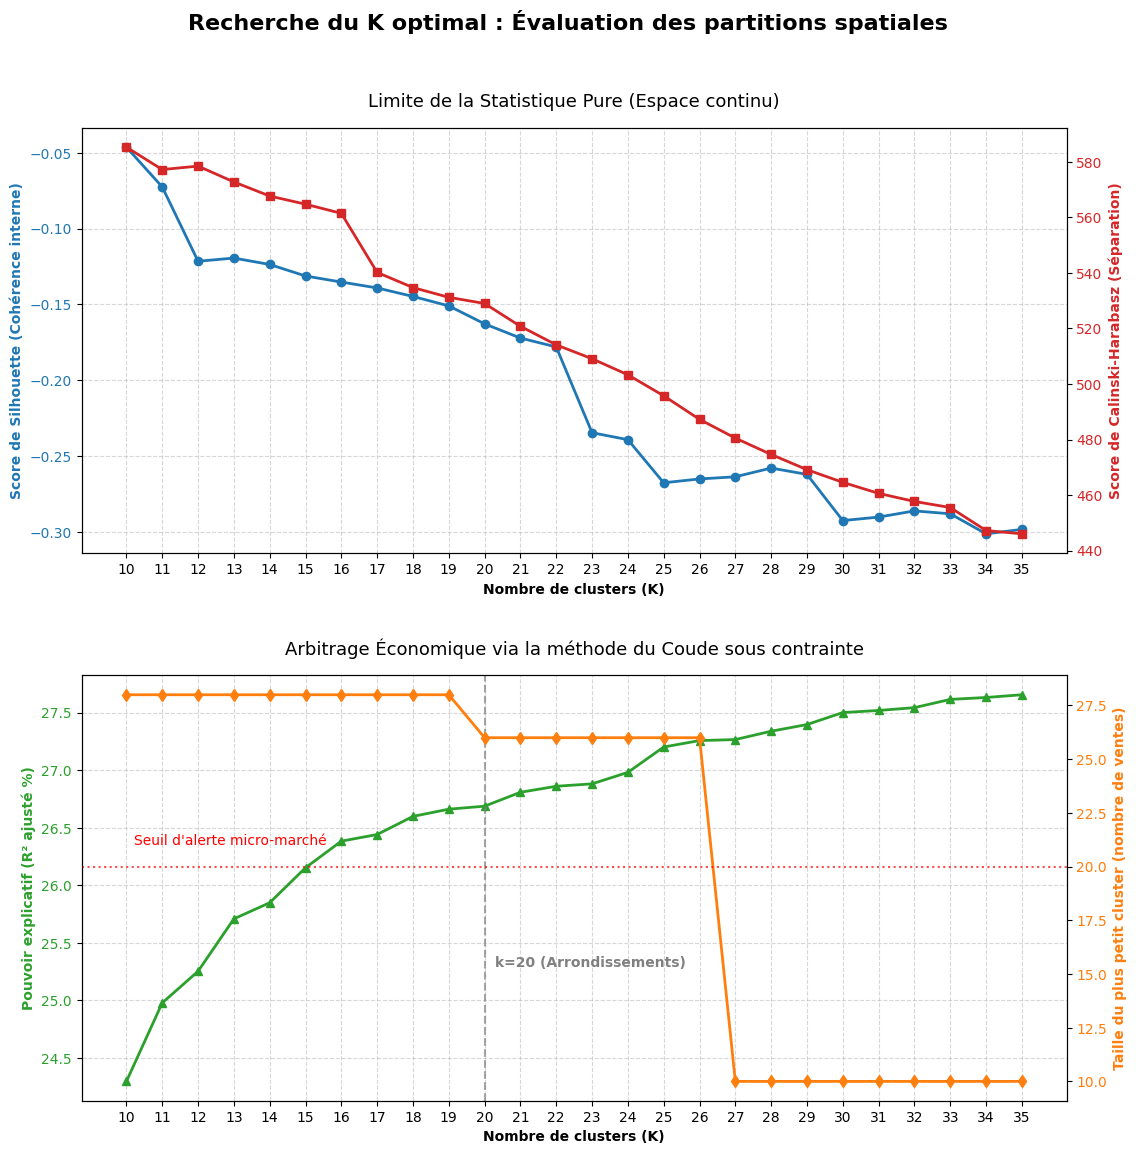

In [36]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

print("Discipline du K...")

plage_k = range(10, 36)
silhouettes = []
calinskis = []
r2_scores = []
min_cluster_sizes = []

total_transactions = len(df_geocoded_multi)

for k in plage_k:
    model = AgglomerativeClustering(n_clusters=k, connectivity=graphe_multi, linkage='ward')
    labels = model.fit_predict(prix_multi_scaled)
    df_sections_multi[f'cluster_temp_{k}'] = labels
    
    # Métriques statistiques
    silhouettes.append(silhouette_score(prix_multi_scaled, labels))
    calinskis.append(calinski_harabasz_score(prix_multi_scaled, labels))

    # Projection sur les transactions pour calculer le R²
    df_temp = pd.merge(
        df_geocoded_multi[['prix_m2', 'micro_quartier']], 
        df_sections_multi[['micro_quartier', f'cluster_temp_{k}']], 
        on='micro_quartier', 
        how='inner'
    )

    # Taille du plus petit cluster (en % des ventes parisiennes)
    taille_min = df_temp[f'cluster_temp_{k}'].value_counts().min()
    min_cluster_sizes.append(taille_min)
    
    # Calcul du pouvoir explicatif (R²)
    ols_temp = smf.ols(f'prix_m2 ~ C(cluster_temp_{k})', data=df_temp).fit()
    r2_scores.append(ols_temp.rsquared_adj * 100)

# Visualisation
fig, (ax_stat, ax_eco) = plt.subplots(2, 1, figsize=(12, 12))

# Statistiques de cohérence et séparation
ax_stat.set_xticks(plage_k)
ax_stat.set_xlabel('Nombre de clusters (K)', fontweight='bold')
ax_stat.set_ylabel('Score de Silhouette (Cohérence interne)', color='tab:blue', fontweight='bold')
ax_stat.plot(plage_k, silhouettes, marker='o', color='tab:blue', linewidth=2)
ax_stat.tick_params(axis='y', labelcolor='tab:blue')

ax_stat_2 = ax_stat.twinx()  
ax_stat_2.set_ylabel('Score de Calinski-Harabasz (Séparation)', color='tab:red', fontweight='bold')  
ax_stat_2.plot(plage_k, calinskis, marker='s', color='tab:red', linewidth=2)
ax_stat_2.tick_params(axis='y', labelcolor='tab:red')

ax_stat.set_title("Limite de la Statistique Pure (Espace continu)", fontsize=13, pad=15)
ax_stat.grid(True, linestyle='--', alpha=0.5)

# Pouvoir explicatif et taille des clusters
ax_eco.set_xticks(plage_k)
ax_eco.set_xlabel('Nombre de clusters (K)', fontweight='bold')
ax_eco.set_ylabel('Pouvoir explicatif (R² ajusté %)', color='tab:green', fontweight='bold')
ax_eco.plot(plage_k, r2_scores, marker='^', color='tab:green', linewidth=2)
ax_eco.tick_params(axis='y', labelcolor='tab:green')

# On marque le K=20 (notre choix interprétable)
ax_eco.axvline(x=20, color='gray', linestyle='--', alpha=0.7)
ax_eco.text(20.3, min(r2_scores) + 1, "k=20 (Arrondissements)", color='gray', fontweight='bold')

ax_eco_2 = ax_eco.twinx()  
ax_eco_2.set_ylabel('Taille du plus petit cluster (nombre de ventes)', color='tab:orange', fontweight='bold')  
ax_eco_2.plot(plage_k, min_cluster_sizes, marker='d', color='tab:orange', linewidth=2)
ax_eco_2.tick_params(axis='y', labelcolor='tab:orange')

# On ajoute un seuil de viabilité économique (ex: 20 transactions)
seuil = 20
ax_eco_2.axhline(y=seuil, color='red', linestyle=':', alpha=0.7)
ax_eco_2.text(10.2, 21, "Seuil d'alerte micro-marché", color='red')

ax_eco.set_title("Arbitrage Économique via la méthode du Coude sous contrainte", fontsize=13, pad=15)
ax_eco.grid(True, linestyle='--', alpha=0.5)

fig.suptitle("Recherche du K optimal : Évaluation des partitions spatiales", fontsize=16, fontweight='bold', y=0.98)
fig.tight_layout(pad=3.0)  
plt.show()

## Conclusion de la phase 4

L'examen approfondi des indicateurs apporte des conclusions méthodologiques fondamentales :

1. **Échec de la statistique pure (Gradient continu) :** Les coefficients de Silhouette et de Calinski-Harabasz sont décroissants. Dans un espace urbain dense comme Paris, les prix forment un gradient spatial continu (Est/Ouest) plutôt que des "îles" isolées par du vide. La statistique pure refuse la frontière et cherche à conserver une macro-unité binaire, ce qui est inexploitable à l'échelle locale.
2. **Validation du Coude Économique :** Le $R^2$ ajusté montre une forme concave avec un point d'inflexion (rendement marginal décroissant) situé autour de $k=18$. Au-delà de $k=21$, multiplier les clusters n'apporte plus aucun gain substantiel de pouvoir explicatif.
3. **Le précipice de l'instabilité ($k=27$) :** L'analyse de la taille minimale révèle qu'à partir de $k=27$, l'algorithme isole un micro-marché résiduel de seulement 10 transactions sur 4 ans, franchissant le seuil critique de viabilité statistique.

**Arbitrage final :** La contrainte exogène $k=20$ se situe exactement dans la zone de performance optimale du R² (26.7 %), préserve la densité statistique de chaque sous-marché et garantit une parfaite comparabilité avec le maillage administratif des 20 arrondissements.